**Importing the libraries**

In [1]:
import numpy as np
import tensorflow as tf
import glob 
import os 
from PIL import Image
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Input
import warnings

2025-02-01 10:20:13.259150: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-01 10:20:13.277208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738405213.299140   14070 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738405213.305362   14070 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-01 10:20:13.323752: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
warnings.filterwarnings("ignore")

In [ ]:
os.mkdir('train_data')
os.mkdir('test_data')
os.mkdir('train_data/benign')
os.mkdir('train_data/malicious')
os.mkdir('test_data/benign')
os.mkdir('test_data/malicious')
os.mkdir('validation_data')
os.mkdir('validation_data/benign')
os.mkdir('validation_data/malicious')

In [ ]:
import zipfile
zip_file_path = 'archive (1).zip'
extraction_dir = ''

# Extract the contents of the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)



In [ ]:
import shutil

benign_image= os.listdir("QR codes/benign/benign")

for i in range(len(benign_image)):
    if(i<50000):
        shutil.copy("QR codes/benign/benign/"+benign_image[i],"train_data/benign")
    elif(i<65000):
        shutil.copy("QR codes/benign/benign/"+benign_image[i],"validation_data/benign")
    else:
        shutil.copy("QR codes/benign/benign/"+benign_image[i],"test_data/benign")

malicious_image= os.listdir("QR codes/malicious/malicious")

for i in range(len(malicious_image)):
    if(i<50000):
        shutil.copy("QR codes/malicious/malicious/"+malicious_image[i],"train_data/malicious")
    elif(i<65000):
        shutil.copy("QR codes/malicious/malicious/"+malicious_image[i],"validation_data/malicious")
    else:
        shutil.copy("QR codes/malicious/malicious/"+malicious_image[i],"test_data/malicious")

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_gen= ImageDataGenerator(rescale=1./255)

In [4]:
train_generator = data_gen.flow_from_directory(
    "train_data",  
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)
val_data = data_gen.flow_from_directory(
    "validation_data",
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)
test_data= data_gen.flow_from_directory(
    "test_data",
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)

Found 100000 images belonging to 2 classes.
Found 30000 images belonging to 2 classes.
Found 70000 images belonging to 2 classes.


In [5]:

model = Sequential()
model.add(Input(shape=(410,410, 3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(64, activation='relu'))

model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
model.summary()

I0000 00:00:1738405223.100746   14070 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10527 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:1b:00.0, compute capability: 6.1
I0000 00:00:1738405223.101425   14070 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 10527 MB memory:  -> device: 1, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:1d:00.0, compute capability: 6.1
I0000 00:00:1738405223.101935   14070 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 10527 MB memory:  -> device: 2, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:1e:00.0, compute capability: 6.1
I0000 00:00:1738405223.102429   14070 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 10527 MB memory:  -> device: 3, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:3d:00.0, compute capability: 6.1
I0000 00:00:1738405223.102920   14070 gpu_de

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 408, 408, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 204, 204, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 202, 202, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 101, 101, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 99, 99, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 153664)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,669,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,753,154 (75.35 MB)

 Trainable params: 19,753,154 (75.35 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history= model.fit(train_generator, epochs=10,validation_data=val_data,verbose=1)

Epoch 1/10


I0000 00:00:1738405228.564189   14343 service.cc:148] XLA service 0x763118022510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738405228.564242   14343 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738405228.564248   14343 service.cc:156]   StreamExecutor device (1): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738405228.564251   14343 service.cc:156]   StreamExecutor device (2): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738405228.564255   14343 service.cc:156]   StreamExecutor device (3): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738405228.564259   14343 service.cc:156]   StreamExecutor device (4): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738405228.564263   14343 service.cc:156]   StreamExecutor device (5): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2025-02-01 10:20:28.644797:

 418/1563 ━━━━━━━━━━━━━━━━━━━━ 5:16 277ms/step - accuracy: 0.8645 - loss: 0.5560

2025-02-01 10:22:41.346279: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[32,64,202,202]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,204,204]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-02-01 10:22:42.460561: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[32,64,99,99]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,101,101]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9462 - loss: 0.2079  

2025-02-01 10:28:08.280858: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,64,408,408]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,410,410]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-02-01 10:28:08.403484: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.122767891s
Trying algorithm eng0{} for conv (f32[64,64,408,408]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,410,410]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_con

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 572s 355ms/step - accuracy: 0.9463 - loss: 0.2078 - val_accuracy: 0.9989 - val_loss: 0.0033
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 537s 344ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9977 - val_loss: 0.0075
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 535s 342ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9981 - val_loss: 0.0066
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 538s 344ms/step - accuracy: 0.9997 - loss: 8.6161e-04 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 535s 342ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9998 - val_loss: 0.0012
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 532s 340ms/step - accuracy: 1.0000 - loss: 1.3120e-04 - val_accuracy: 0.9992 - val_loss: 0.0029
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 536s 343ms/step - accuracy: 1.0000 - loss: 4.9609e-06 - val_accuracy: 0.9998 - val_loss: 0.0012
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 535s 342ms/step - a

In [7]:
loss, accuracy = model.evaluate(test_data, steps=test_data.samples // test_data.batch_size, verbose=1)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")


1093/1093 ━━━━━━━━━━━━━━━━━━━━ 269s 246ms/step - accuracy: 0.9999 - loss: 6.7759e-04
Loss: 0.000908185204025358
Accuracy: 0.9999142289161682


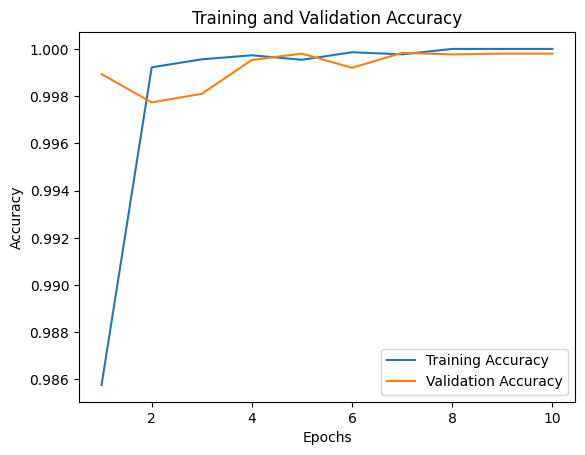

In [9]:
train_accuracy = history.history['accuracy']  
val_accuracy = history.history['val_accuracy']  
epochs = range(1, len(train_accuracy) + 1)  
import matplotlib.pyplot as plt

plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.savefig("Accuracy_Adam.png")

plt.show()

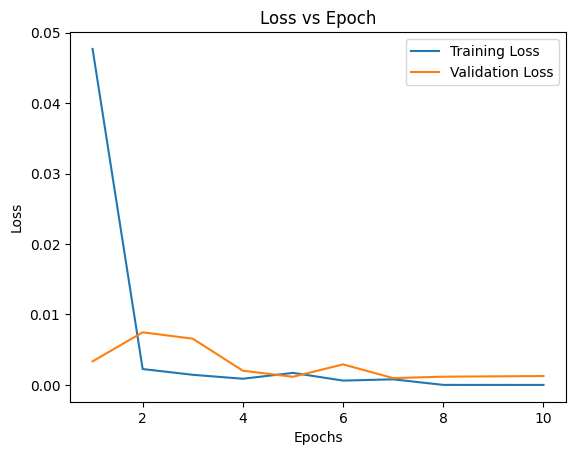

In [10]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']  

plt.plot(epochs, loss_values, label='Training Loss')  
plt.plot(epochs, val_loss_values, label='Validation Loss') 
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig("Loss_Adam.png")
plt.show()

In [11]:
model.save("QR_Code_Classifier_adam.h5")

In [14]:
model.save_weights('adam_model.weights.h5')

Benign-0 Malicious-1

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = 'QR codes/benign/benign/benign_40.png'

img = image.load_img(img_path,) 

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)


img_array /= 255.0 

img_array.shape

prediction= model.predict(img_array)
print(np.argmax(prediction))


(370, 370, 3)

In [ ]:
img_path = 'QR codes/malicious/malicious/malicious_316270.png'

img = image.load_img(img_path, target_size=(224, 224)) 

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array /= 255.0 
img_array.shape

# prediction= model.predict(img_array)
# print(np.argmax(prediction))